<a href="https://colab.research.google.com/github/Psabo-LUC/systems_modelling_toolkit_PS/blob/main/interactive_1.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/huskeypm/systems_modelling_toolkit

Cloning into 'systems_modelling_toolkit'...
remote: Enumerating objects: 204, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 204 (delta 30), reused 26 (delta 26), pack-reused 168 (from 1)
Receiving objects: 100% (204/204), 9.68 MiB | 9.09 MiB/s, done.
Resolving deltas: 100% (94/94), done.


In [3]:
import numpy as np
from parse import parse_interactions, parse_substrates, parse_rates
from network import Network

In [86]:
import gspread
import pandas as pd
from google.auth import default
from google.colab import auth
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)


ID ='1XnIBId92mB9ENdx51SPp-6AAXcIzmQobwDhixFjI72w' #Substrates.csv
filename = "substrates.csv"

#ID = '12VSH1FUDArC5Z5Q5p5TsWeqWIvvaSpGyKbfdXpE_Mkg' #rates.csv
#filename = "rates.csv"

#ID = '17qAI5AJd-ct5lj92WAsTIruBaSXdeORh66BAdrK3kc4' #interactions.csv
#filename = "interactions.csv"


spreadsheet = gc.open_by_key(ID)



worksheet = spreadsheet.get_worksheet(0)
print(worksheet)
df = pd.DataFrame(worksheet.get())
# Code for making the first row as header. Remove if not needed.
df.columns = df.iloc[0]
df = df.drop(0)
df.head()
print(df)

<Worksheet 'Sheet1' id:0>
0     name initial_value substrate_type activation_rate deactivation_rate  \
1  0  Stim             0       stimulus                                     
2  1     A             0         enzyme           A_act           A_deact   
3  2     B             0         enzyme           B_act           B_deact   
4  3     C             0       stimulus                         D_degrade   

0 total_amt other_state active_time_ranges  
1         0                        120,240  
2       1.0        None               None  
3       1.0        None               None  
4       1.0                         0,1000  


In [87]:
from google.colab import sheets
url = "https://docs.google.com/spreadsheets/d/" + ID
sheet = sheets.InteractiveSheet(url = url)

https://docs.google.com/spreadsheets/d/1XnIBId92mB9ENdx51SPp-6AAXcIzmQobwDhixFjI72w/edit#gid=0


In [88]:
from google.colab import drive
drive.mount('/content/drive')

df = sheet.as_df()
#worksheet.clear()
sheet.update(df)
#!ls "/content/drive/MyDrive/Modeling_parameters/"
df.to_csv("/content/drive/MyDrive/Modeling_parameters/" + filename, index = False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
import sys
MYPATH="/content/systems_modelling_toolkit/"
sys.path.append('/content/systems_modelling_toolkit/src')


In [99]:


# 1. Parse your baseline topology
DATAPATH= "/content/drive/MyDrive/Modeling_parameters/"

interactions = parse_interactions(DATAPATH + "interactions.csv")
substrates = parse_substrates(DATAPATH + "substrates.csv")
rates = parse_rates(DATAPATH + "rates.csv")

n = Network("custom_run", rates, substrates, interactions)

DATAPATH=MYPATH+"/data/pi3k_pten/"

# 2. Load the fitted parameters (this overwrites the base rates in memory)
n.load_adapter(DATAPATH + "adapter_expanded.json")

# 3. Setup time resolution (e.g., 1000 minutes, 10000 steps)
time = np.linspace(0, 999, num=10000)

# 4. Dial in your custom conditions
# Example: Dosing with 2.0 AU of LPS and 1.5 AU of ATP from t=0 to t=60
n.apply_stimuli(
    stimuli=["Stim"],
    amts=[1.0],
    time_ranges=[[120, 180]]
)
# 5. Run the ODEs
y = n.y(time, steady_state_fold_normalization=False)

# 6. Save the track and reset for the next condition
n.store_track(y, time, MYPATH+"/outputs/my_custom_run.csv")
n.reset_stimuli()



In [138]:
import pandas as pd
import matplotlib.pyplot as plt

def doit(df):
  # The first column is the time steps, but it's missing a header name in the CSV.
  # We will rename it to 'Time' and set it as the index.
  df.rename(columns={df.columns[0]: 'Time'}, inplace=True)
  df.set_index('Time', inplace=True)

  # 2. Select which substrates you actually want to see.
  # (Plotting all 16 at once gets messy, so specify the key ones here)
  substrates_to_plot = ["Stim", "A", "B", "C"]

  # 3. Create the plot
  plt.figure(figsize=(8, 5))
  for substrate in substrates_to_plot:
      if substrate in df.columns:
          plt.plot(df.index, df[substrate], label=substrate)

  # 4. Format it exactly like the author's internal network.py grapher
  plt.xlabel("Time (mins)", fontsize=12)
  plt.ylabel("Concentration (AU)", fontsize=12)
  plt.legend(loc="upper right", fontsize=10)
  plt.title("Pathway Activation Over Time")

  # Save and show
  plt.tight_layout()
  plt.savefig("figure.png", dpi=300)
  print("Saved plot to figure?.png")


#if __name__ == "__main__":
  # 1. Load the CSV
#  csv_path = "../outputs/my_custom_run.csv"  # Change this to your CSV path
#  df = pd.read_csv(csv_path)
#  doit(df)

Index(['Unnamed: 0', 'Stim', 'A', 'B', 'C'], dtype='object')
Saved plot to figure?.png


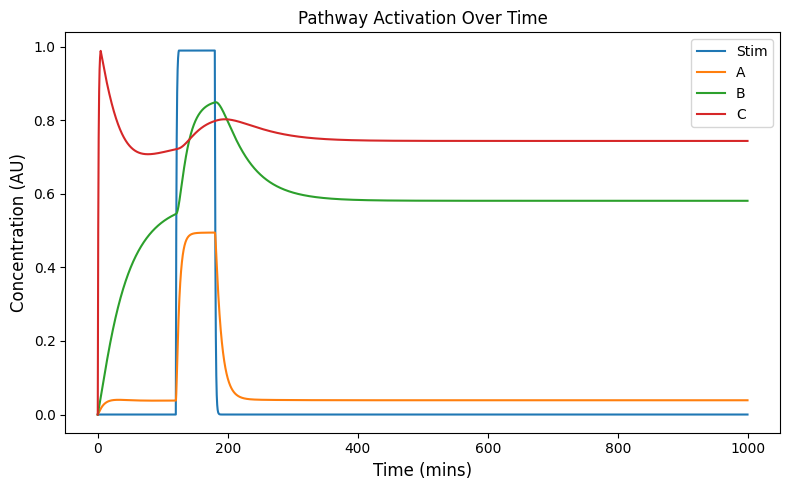

In [139]:
# 1. Load the CSV (overkill)
import pandas as pd
csv_path = MYPATH+"/outputs/my_custom_run.csv"  # Change this to your CSV path
df = pd.read_csv(csv_path)
print(df.columns)
doit(df)